In [1]:
import sys

sys.path.insert(0, "/home/emaragliano/myfarm-disk/AE_storage_Paper2/UNetModelMasked/")
print(sys.path)
from importlib import reload

from OutputReaders import OutputReader, Plotter, set_latex_env
#reload(sys.modules["OutputReaders"])
set_latex_env()

['/home/emaragliano/myfarm-disk/AE_storage_Paper2/UNetModelMasked/', '/mnt/project_mnt/farm_fs/emaragliano/AE_storage_Paper2/UNetModelMasked/tests', '/home/emaragliano/Pylians/library/build/lib.linux-x86_64-2.7', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python310.zip', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/lib-dynload', '', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages', '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction', '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Recon_challenge', '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/MyThesisLib_dev']


In [2]:
import os
import numpy as np

In [3]:
punyas_dict = {
    'trained_RSD': {
        'sm_15': 'AE_128_final_haloRSD_haloReal_CIC',
        'sm_10': 'AE_128_final_haloRSD_haloReal_CIC',
        'sm_5': 'AE_128_final_haloRSD_haloReal_CIC',
    }, 
    'trained_ZA': {
        'sm_15': 'AE_128_final_haloRSD_haloReal_zeld_15mpc',
        'sm_10': 'AE_128_final_haloRSD_haloReal_zeld_10mpc',
        'sm_5': 'AE_128_final_haloRSD_haloReal_zeld_5mpc',
    },
}

sm_label = 'sm_10'

In [4]:
punyas_folder = '/farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS'


xi_map_NN_trained_on_RSD = os.path.join(punyas_folder, punyas_dict['trained_RSD'][sm_label],\
                                  'density_from_redshift_500epoch_20samples.npy')

xi_map_NN_trained_on_ZA = os.path.join(punyas_folder, punyas_dict['trained_ZA'][sm_label],\
                                    'density_from_redshift_500epoch_20samples.npy')

In [5]:
xi_map_NN_trained_on_RSD

'/farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS/AE_128_final_haloRSD_haloReal_CIC/density_from_redshift_500epoch_20samples.npy'

In [6]:
parent_folder = '/farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/TRAINING_DATA/'

In [7]:
reader = OutputReader(
    real_space      = os.path.join(parent_folder, "observed", "halo_number_density_real_space_*_128_CIC_group_tab_002.npy"),
    lt_rec          = os.path.join(parent_folder, "zeldovich", "zeldovich_rec_density_*_from_redshift_space_128_CIC_sm_10_zeldareco.npy"),
    redshift_space  = os.path.join(parent_folder, "observed", "halo_number_density_redshift_space_*_128_CIC_group_tab_002.npy"),
    nn_rec          = xi_map_NN_trained_on_RSD,
    lt_nn_rec       = xi_map_NN_trained_on_ZA
)


OutputReader inizializzato


In [8]:
reader.load_fields(idxs=np.arange(80,100))

Imported data for mode: real_space
Imported data for mode: redshift_space
Imported data for mode: lt_rec
Loading all NN reconstructed fields from a single file.
File path: /farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS/AE_128_final_haloRSD_haloReal_CIC/density_from_redshift_500epoch_20samples.npy
all_mocks shape: (20, 128, 128, 128, 1) Formatting...
all_mocks formatted shape: (20, 128, 128, 128)
Imported data for mode: nn_rec
Loading all NN reconstructed fields from a single file.
File path: /farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS/AE_128_final_haloRSD_haloReal_zeld_10mpc/density_from_redshift_500epoch_20samples.npy
all_mocks shape: (20, 128, 128, 128, 1) Formatting...
all_mocks formatted shape: (20, 128, 128, 128)
Imported data for mode: lt_nn_rec


In [9]:
reader.compute_all_stats(
    modes=['real_space', 'redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'],
    box_size=1000.0,
    grid_size=128,
    box_centre=[500.0, 500.0, 500.0]
)

Computing pk_multipoles for mode: real_space


100%|██████████| 20/20 [00:04<00:00,  4.60it/s]


Computing pk_multipoles for mode: redshift_space


100%|██████████| 20/20 [00:04<00:00,  4.63it/s]


Computing pk_multipoles for mode: lt_rec


...

Computing pk_multipoles for mode: nn_rec


100%|██████████| 20/20 [00:04<00:00,  4.66it/s]


Computing pk_multipoles for mode: lt_nn_rec


100%|██████████| 20/20 [00:04<00:00,  4.65it/s]

discr_array shape: (20, 3, 62)
discr_array shape: (20, 3, 62)
discr_array shape: (20, 3, 62)
discr_array shape: (20, 3, 62)


In [10]:
reader.pk_residuals.keys()

dict_keys(['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'])

In [11]:
k = reader.k_values

In [12]:
import matplotlib.pyplot as plt

In [14]:
reader.pk_residuals.keys()

dict_keys(['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'])

In [34]:
reload(sys.modules["OutputReaders"])
from OutputReaders import Plotter, set_latex_env

In [35]:
#set_latex_env()

### Test plotting methods

(<Figure size 1400x400 with 3 Axes>,
 array([<Axes: xlabel='$k\\, [h~\\mathrm{Mpc}^{-1}]$', ylabel='residuals'>,
        <Axes: xlabel='$k\\, [h~\\mathrm{Mpc}^{-1}]$', ylabel='residuals'>,
        <Axes: xlabel='$k\\, [h~\\mathrm{Mpc}^{-1}]$', ylabel='residuals'>],
       dtype=object))

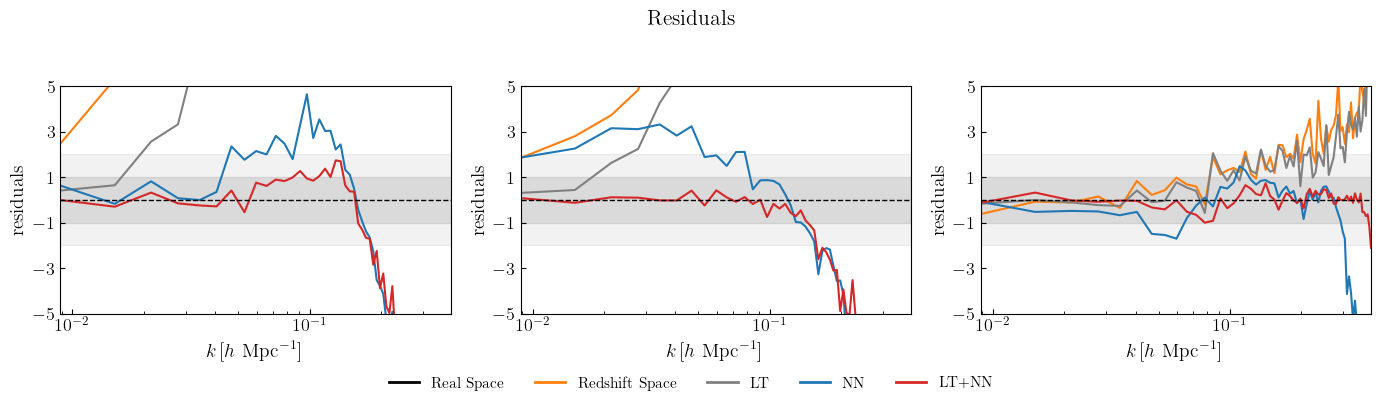

In [36]:
my_plotter = Plotter(reader)

my_plotter.plot_pk_residuals(
    modes=['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'],
    title=' Residuals'

)

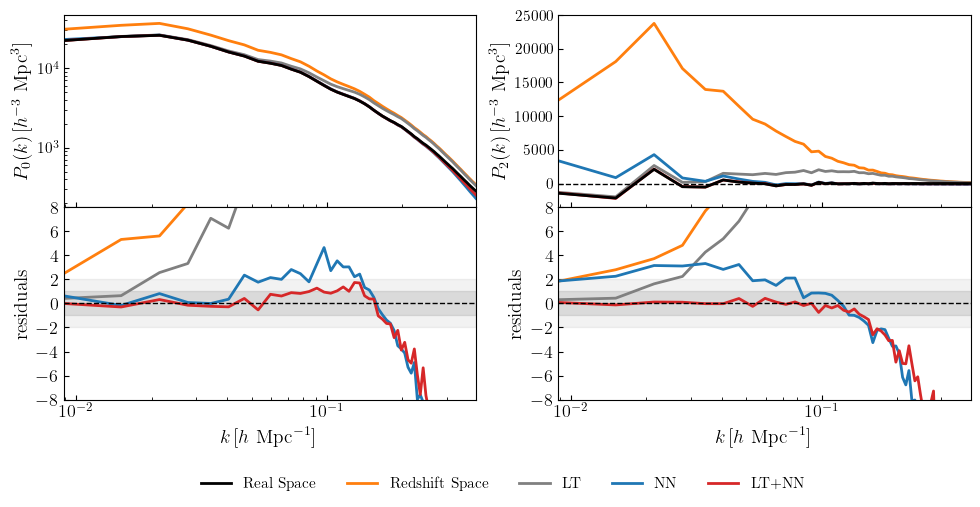

In [37]:
my_plotter.plot_pk_multipoles_and_residuals(
    modes=['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'],
    title=None,
    RESPANELYLIM=8,
    multipoles=[0,2],
    share_col=True,
    hspace=None
)
plt.show()